In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report

In [5]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

df.head()


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [6]:
print(df.shape)
print(df.columns.tolist())
df.info()
df.describe(include="all")

(7214, 53)
['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
count,7214.000000,7214,7214,7214,7214,7214,7214,7214.000000,7214,7214,...,7214.000000,7214,7214,6978,6978,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000
unique,NaN,7158,2800,3950,690,2,5452,NaN,3,6,...,NaN,3,690,1156,1169,NaN,NaN,NaN,NaN,NaN
top,NaN,anthony smith,michael,williams,2013-03-20,Male,1994-07-15,NaN,25 - 45,African-American,...,NaN,Low,2013-03-20,2013-02-22,2020-01-01,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,149,83,32,5819,5,NaN,4109,3696,...,NaN,4761,32,20,61,NaN,NaN,NaN,NaN,NaN
mean,5501.255753,NaN,NaN,NaN,NaN,NaN,NaN,34.817993,NaN,NaN,...,3.691849,NaN,NaN,NaN,NaN,3.472415,11.465068,553.436651,0.382867,0.450652
std,3175.706870,NaN,NaN,NaN,NaN,NaN,NaN,11.888922,NaN,NaN,...,2.510148,NaN,NaN,NaN,NaN,4.882538,46.954563,399.020583,0.486120,0.497593
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2735.250000,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,148.250000,0.000000,0.000000
50%,5509.500000,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,...,3.000000,NaN,NaN,NaN,NaN,2.000000,0.000000,530.500000,0.000000,0.000000
75%,8246.500000,NaN,NaN,NaN,NaN,NaN,NaN,42.000000,NaN,NaN,...,5.000000,NaN,NaN,NaN,NaN,5.000000,1.000000,914.000000,1.000000,1.000000


In [7]:
cols = [
    "age",
    "age_cat",
    "sex",
    "race",
    "priors_count",
    "c_charge_degree",
    "score_text",
    "decile_score",
    "days_b_screening_arrest",
    "is_recid",
    "c_jail_in",
    "c_jail_out",
    "two_year_recid"
]

compas = df[cols].copy()
compas.head()

,age,age_cat,sex,race,priors_count,c_charge_degree,score_text,decile_score,days_b_screening_arrest,is_recid,c_jail_in,c_jail_out,two_year_recid
0,69,Greater than 45,Male,Other,0,F,Low,1,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,0
1,34,25 - 45,Male,African-American,0,F,Low,3,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53,1
2,24,Less than 25,Male,African-American,4,F,Low,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04,1
3,23,Less than 25,Male,African-American,1,F,High,8,NaN,0,NaN,NaN,0
4,43,25 - 45,Male,Other,2,F,Low,1,NaN,0,NaN,NaN,0


In [8]:
cols = [
    "age",
    "age_cat",
    "sex",
    "race",
    "priors_count",
    "c_charge_degree",
    "score_text",
    "decile_score",
    "days_b_screening_arrest",
    "is_recid",
    "c_jail_in",
    "c_jail_out",
    "two_year_recid"
]

compas = df[cols].copy()
compas.head()

,age,age_cat,sex,race,priors_count,c_charge_degree,score_text,decile_score,days_b_screening_arrest,is_recid,c_jail_in,c_jail_out,two_year_recid
0,69,Greater than 45,Male,Other,0,F,Low,1,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,0
1,34,25 - 45,Male,African-American,0,F,Low,3,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53,1
2,24,Less than 25,Male,African-American,4,F,Low,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04,1
3,23,Less than 25,Male,African-American,1,F,High,8,NaN,0,NaN,NaN,0
4,43,25 - 45,Male,Other,2,F,Low,1,NaN,0,NaN,NaN,0


In [9]:
compas = compas[
    (compas["is_recid"] != -1) &
    (compas["score_text"] != "N/A") &
    (compas["c_charge_degree"] != "O")
].copy()

print(compas.shape)
compas.head()

(7214, 13)


,age,age_cat,sex,race,priors_count,c_charge_degree,score_text,decile_score,days_b_screening_arrest,is_recid,c_jail_in,c_jail_out,two_year_recid
0,69,Greater than 45,Male,Other,0,F,Low,1,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,0
1,34,25 - 45,Male,African-American,0,F,Low,3,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53,1
2,24,Less than 25,Male,African-American,4,F,Low,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04,1
3,23,Less than 25,Male,African-American,1,F,High,8,NaN,0,NaN,NaN,0
4,43,25 - 45,Male,Other,2,F,Low,1,NaN,0,NaN,NaN,0


In [10]:
compas.isna().sum()

,0
age,0
age_cat,0
sex,0
race,0
priors_count,0
c_charge_degree,0
score_text,0
decile_score,0
days_b_screening_arrest,307
is_recid,0


In [11]:
print(compas["race"].value_counts())
print(compas["score_text"].value_counts())
print(compas["two_year_recid"].value_counts())
print(compas["sex"].value_counts())

race
African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18
Name: count, dtype: int64
score_text
Low       3897
Medium    1914
High      1403
Name: count, dtype: int64
two_year_recid
0    3963
1    3251
Name: count, dtype: int64
sex
Male      5819
Female    1395
Name: count, dtype: int64


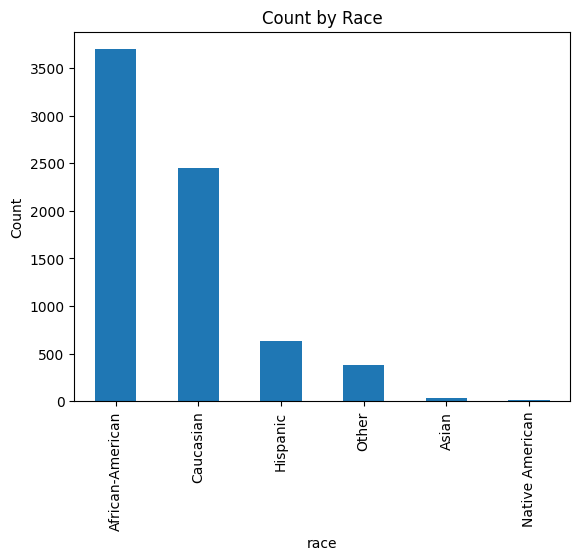

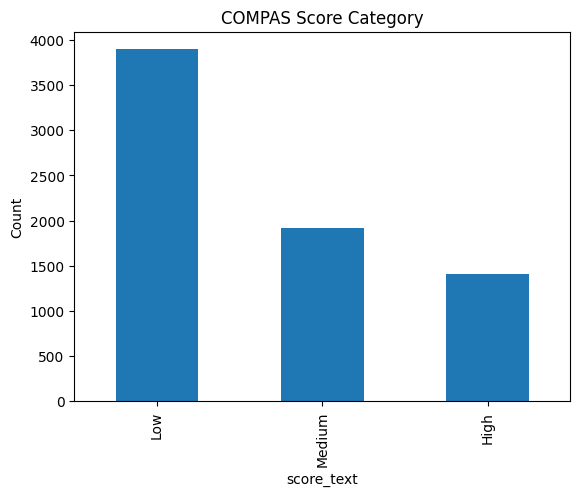

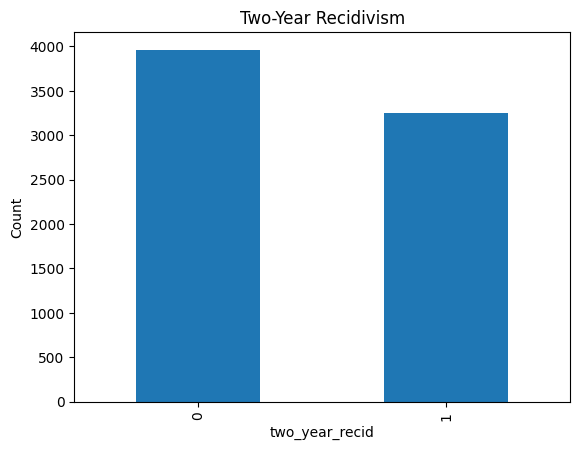

In [12]:
compas["race"].value_counts().plot(kind="bar")
plt.title("Count by Race")
plt.ylabel("Count")
plt.show()

compas["score_text"].value_counts().plot(kind="bar")
plt.title("COMPAS Score Category")
plt.ylabel("Count")
plt.show()

compas["two_year_recid"].value_counts().plot(kind="bar")
plt.title("Two-Year Recidivism")
plt.ylabel("Count")
plt.show()

In [13]:
compas["pred_high_risk"] = np.where(compas["decile_score"] >= 7, 1, 0)
compas[["decile_score", "pred_high_risk"]].head()

,decile_score,pred_high_risk
0,1,0
1,3,0
2,4,0
3,8,1
4,1,0


In [14]:
cm = confusion_matrix(compas["two_year_recid"], compas["pred_high_risk"])
print(cm)

[[3319  644]
 [1900 1351]]


In [15]:
def group_confusion_metrics(data, group_col="race"):
    results = []

    for group, g in data.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            g["two_year_recid"],
            g["pred_high_risk"]
        ).ravel()

        results.append({
            "group": group,
            "n": len(g),
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "accuracy": (tp + tn) / len(g),
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

group_metrics = group_confusion_metrics(compas)
group_metrics

,group,n,TP,FP,TN,FN,accuracy,FPR,FNR
0,African-American,3696,978,447,1348,923,0.629329,0.249025,0.485534
2,Caucasian,2454,283,136,1352,683,0.666259,0.091398,0.707039
3,Hispanic,637,54,47,358,178,0.646782,0.116049,0.767241
5,Other,377,25,11,233,108,0.684350,0.045082,0.812030
1,Asian,32,3,1,22,6,0.781250,0.043478,0.666667
4,Native American,18,8,2,6,2,0.777778,0.250000,0.200000


In [16]:
calibration_table = (
    compas.groupby(["race", "decile_score"])["two_year_recid"]
    .mean()
    .reset_index()
    .rename(columns={"two_year_recid": "recid_rate"})
)

calibration_table.head(20)

,race,decile_score,recid_rate
0,African-American,1,0.228643
1,African-American,2,0.302799
2,African-American,3,0.419075
3,African-American,4,0.459740
4,African-American,5,0.482192
5,African-American,6,0.559896
6,African-American,7,0.592500
7,African-American,8,0.682451
8,African-American,9,0.707895
9,African-American,10,0.793706


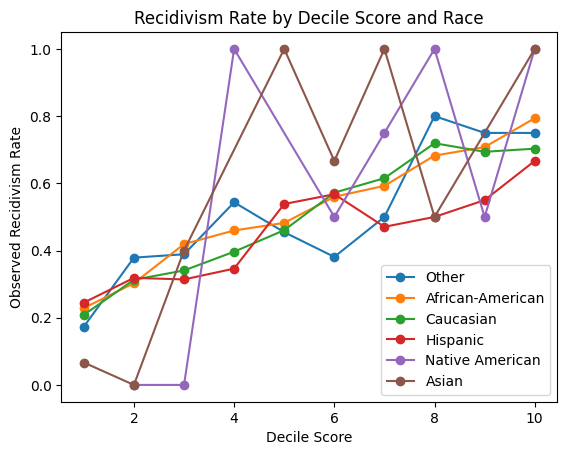

In [17]:
for race in compas["race"].dropna().unique():
    subset = calibration_table[calibration_table["race"] == race]
    plt.plot(subset["decile_score"], subset["recid_rate"], marker="o", label=race)

plt.title("Recidivism Rate by Decile Score and Race")
plt.xlabel("Decile Score")
plt.ylabel("Observed Recidivism Rate")
plt.legend()
plt.show()

In [19]:
model_df = compas[[
    "age",
    "age_cat",
    "sex",
    "race",
    "priors_count",
    "c_charge_degree",
    "score_text",
    "decile_score",
    "days_b_screening_arrest",
    "is_recid",
    "two_year_recid"
]].copy()

model_df = pd.get_dummies(
    model_df,
    columns=["age_cat", "sex", "race", "c_charge_degree", "score_text"],
    drop_first=True
)

print(model_df.shape)
model_df.head()

(7214, 17)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,two_year_recid,age_cat_Greater than 45,age_cat_Less than 25,sex_Male,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,c_charge_degree_M,score_text_Low,score_text_Medium
0,69,0,1,-1.0,0,0,True,False,True,False,False,False,False,True,False,True,False
1,34,0,3,-1.0,1,1,False,False,True,False,False,False,False,False,False,True,False
2,24,4,4,-1.0,1,1,False,True,True,False,False,False,False,False,False,True,False
3,23,1,8,NaN,0,0,False,True,True,False,False,False,False,False,False,False,False
4,43,2,1,NaN,0,0,False,False,True,False,False,False,False,True,False,True,False


In [20]:
X = model_df.drop(columns=["two_year_recid"])
y = model_df["two_year_recid"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(5771, 16) (1443, 16)


In [23]:
model_df = model_df.dropna()

print(model_df.isna().sum())

age                        0
priors_count               0
decile_score               0
days_b_screening_arrest    0
is_recid                   0
two_year_recid             0
age_cat_Greater than 45    0
age_cat_Less than 25       0
sex_Male                   0
race_Asian                 0
race_Caucasian             0
race_Hispanic              0
race_Native American       0
race_Other                 0
c_charge_degree_M          0
score_text_Low             0
score_text_Medium          0
dtype: int64


In [24]:
X = model_df.drop(columns=["two_year_recid"])
y = model_df["two_year_recid"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(5525, 16) (1382, 16)


In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9696092619392185
AUC: 0.9789911895479352
Confusion Matrix:
[[701  42]
 [  0 639]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       743
           1       0.94      1.00      0.97       639

    accuracy                           0.97      1382
   macro avg       0.97      0.97      0.97      1382
weighted avg       0.97      0.97      0.97      1382



In [29]:
coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_table

,feature,coefficient
4,is_recid,8.448842
10,race_Hispanic,0.705598
12,race_Other,0.278658
9,race_Caucasian,0.261506
6,age_cat_Less than 25,0.217888
2,decile_score,0.038831
1,priors_count,0.030198
0,age,0.002211
3,days_b_screening_arrest,-0.002991
5,age_cat_Greater than 45,-0.178946


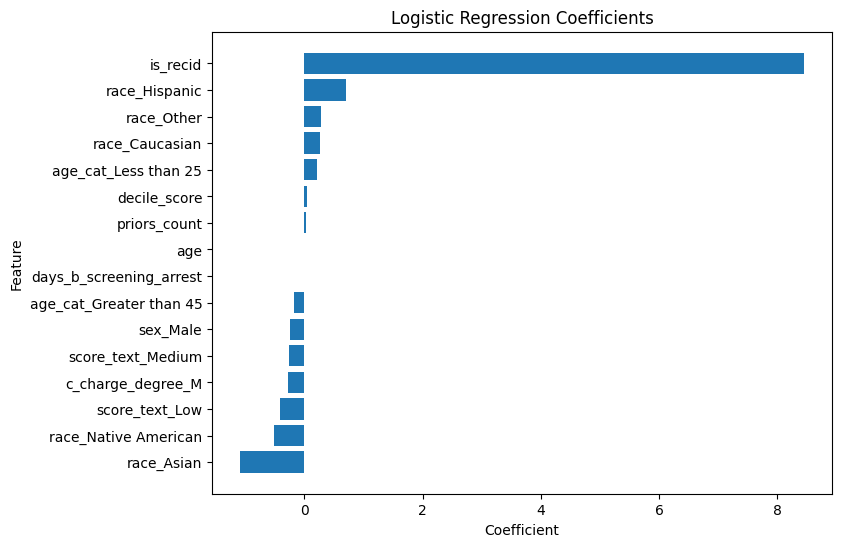

In [30]:
coef_table_sorted = coef_table.sort_values("coefficient")

plt.figure(figsize=(8,6))
plt.barh(coef_table_sorted["feature"], coef_table_sorted["coefficient"])
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In this notebook, I translated the Lecture 01 R workflow into Python using the COMPAS dataset. I followed the same general steps, including loading the data, applying the main filtering rules, exploring the data, and building a logistic regression model to predict two_year_recid.

After training the model, I evaluated its performance using accuracy, AUC, a confusion matrix, and a classification report. Before modeling, I removed missing values to make sure the model would run properly in scikit-learn. Overall, the results are consistent with what we would expect from the R workflow. Any small differences are likely due to differences in how Python and R libraries handle certain calculations.

In [ ]:
Overall, I was able to successfully recreate the R machine learning workflow in Python. The notebook follows the same structure as the original script, including data cleaning, exploratory analysis, model building, and evaluation.

Even though the code syntax is different, the overall logic and results are aligned with the original R version. This shows that the same analytical process can be implemented across different programming languages while still leading to similar conclusions.